In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load prepared Duplicate QC dataset
df = pd.read_csv("../data/processed/duplicates_model.csv")

df.head()


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_DUP_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_DUP_VALUE,UNIT_CODE
0,2021-05-10 11:39:33.000000,TA,3.378640,2.185365,12.5,2.782003,1.193275,42.89,Pass,15.0,MG_KG
1,2021-05-10 11:39:33.000000,TA,-0.746270,0.801886,12.5,0.027808,1.548156,5567.32,Pass,15.0,MG_KG
2,2021-05-10 11:39:33.000000,TA,1.879069,1.260273,12.5,1.569671,0.618796,39.42,Pass,15.0,MG_KG
3,2021-05-10 11:38:57.000000,TA,-3.129188,-2.010870,12.5,-2.570029,1.118317,-43.51,Pass,15.0,MG_KG
4,2021-05-10 11:38:57.000000,TA,-2.185186,-3.709679,12.5,-2.947432,1.524493,-51.72,Pass,15.0,MG_KG


In [4]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Analytes: {df['ANALYTE_CODE'].nunique():,}")

df.info()


Rows: 5,075
Columns: 11
Analytes: 41
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5075 entries, 0 to 5074
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ANALYSED_DATE               5075 non-null   object 
 1   ANALYTE_CODE                4939 non-null   object 
 2   PARENT_NUMERIC_FINAL_VALUE  5075 non-null   float64
 3   NUMERIC_FINAL_VALUE         5075 non-null   float64
 4   STAT_DL_DUP_VALUE           5075 non-null   float64
 5   MEAN_CONC                   5075 non-null   float64
 6   ABS_DIFF                    5075 non-null   float64
 7   RPD                         5075 non-null   float64
 8   PRECISION_STATUS            5075 non-null   object 
 9   LIM_REP_DUP_VALUE           5075 non-null   float64
 10  UNIT_CODE                   5075 non-null   object 
dtypes: float64(7), object(4)
memory usage: 436.3+ KB


In [6]:
# Flag observations above the statistical detection limit
df["ABOVE_STAT_DL"] = df["MEAN_CONC"] > df["STAT_DL_DUP_VALUE"]

analyte_eligibility = (
    df.dropna(subset=["ANALYTE_CODE"])
      .groupby("ANALYTE_CODE")
      .agg(
          TOTAL_OBSERVATIONS=("ANALYTE_CODE", "size"),
          ABOVE_STAT_DL=("ABOVE_STAT_DL", "sum")
      )
)

analyte_eligibility["PCT_ABOVE_STAT_DL"] = (
    analyte_eligibility["ABOVE_STAT_DL"]
    / analyte_eligibility["TOTAL_OBSERVATIONS"]
    * 100
).round(1)

analyte_eligibility = (
    analyte_eligibility
    .sort_values("ABOVE_STAT_DL", ascending=False)
)

analyte_eligibility.head(10)


,TOTAL_OBSERVATIONS,ABOVE_STAT_DL,PCT_ABOVE_STAT_DL
ANALYTE_CODE,,,
AL,136,136,100.0
MN,135,135,100.0
MG,135,134,99.3
RB,136,134,98.5
CO,135,133,98.5
CA,133,132,99.2
FE,131,131,100.0
ZN,132,131,99.2
TI,132,131,99.2


In [7]:
# Assess concentration coverage for eligible observations
df_above_dl = df[
    df["ABOVE_STAT_DL"] &
    df["ANALYTE_CODE"].notna()
].copy()

concentration_coverage = (
    df_above_dl
    .groupby("ANALYTE_CODE")
    .agg(
        OBSERVATIONS=("MEAN_CONC", "size"),
        MIN_CONC=("MEAN_CONC", "min"),
        Q1_CONC=("MEAN_CONC", lambda x: x.quantile(0.25)),
        MEDIAN_CONC=("MEAN_CONC", "median"),
        Q3_CONC=("MEAN_CONC", lambda x: x.quantile(0.75)),
        MAX_CONC=("MEAN_CONC", "max"),
        UNIQUE_CONC=("MEAN_CONC", "nunique")
    )
    .sort_values("OBSERVATIONS", ascending=False)
)

concentration_coverage.head(10)


,OBSERVATIONS,MIN_CONC,Q1_CONC,MEDIAN_CONC,Q3_CONC,MAX_CONC,UNIQUE_CONC
ANALYTE_CODE,,,,,,,
AL,136,0.054479,6.247818,6.771706,7.602067,11.683402,133
MN,135,36.924000,341.908589,514.409972,1119.337867,16829.723530,132
MG,134,0.105934,0.798929,1.062926,1.924504,7.051819,131
RB,134,13.686523,79.528211,126.031573,171.012760,1182.513977,130
CO,133,3.530815,10.041586,13.409216,28.446587,105.034462,130
CA,132,0.033283,0.386623,0.684865,2.787496,7.756077,129
TI,131,0.038451,0.264928,0.339812,0.615149,2.010969,131
ZN,131,5.856434,26.693196,47.026888,93.707400,5138.736434,131
FE,131,0.181164,3.317353,4.189131,8.466041,30.287895,131


## Pilot Analyte Selection

Candidate analytes are assessed for sufficient observations above the
statistical detection limit and adequate coverage across the observed
concentration range.


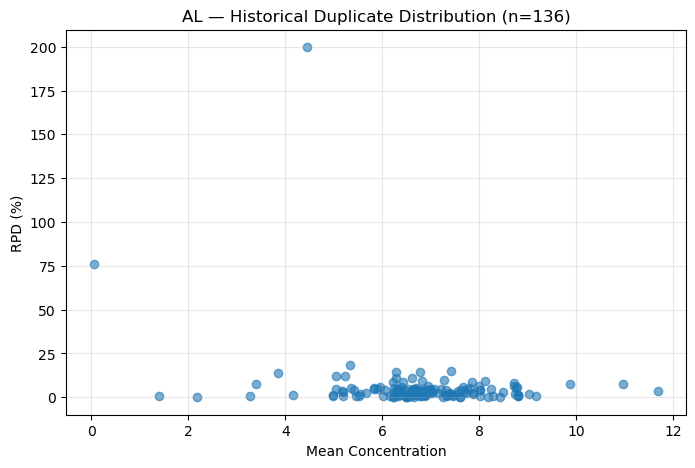

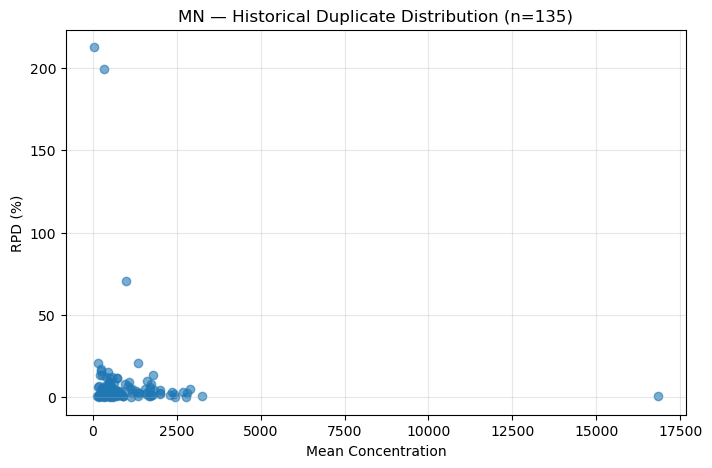

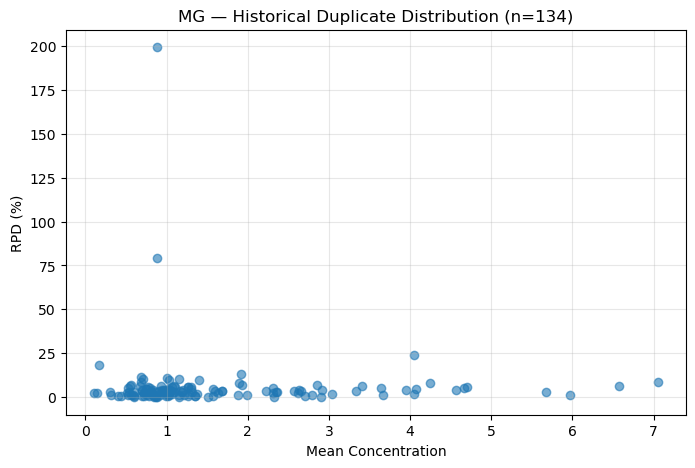

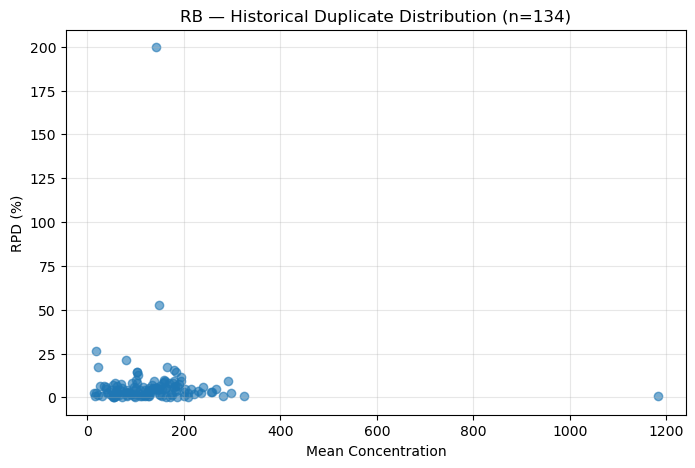

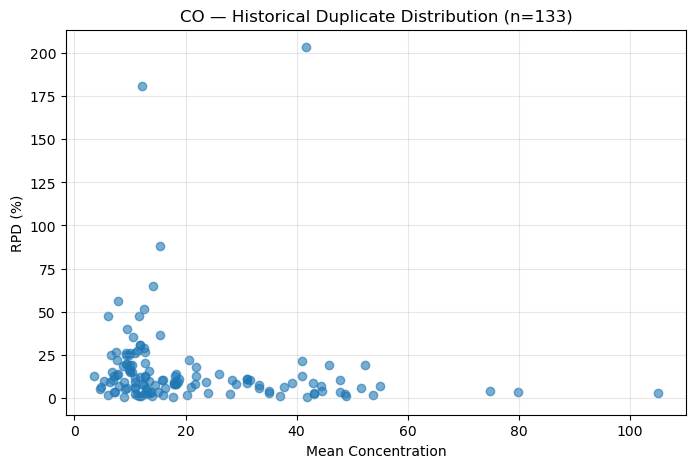

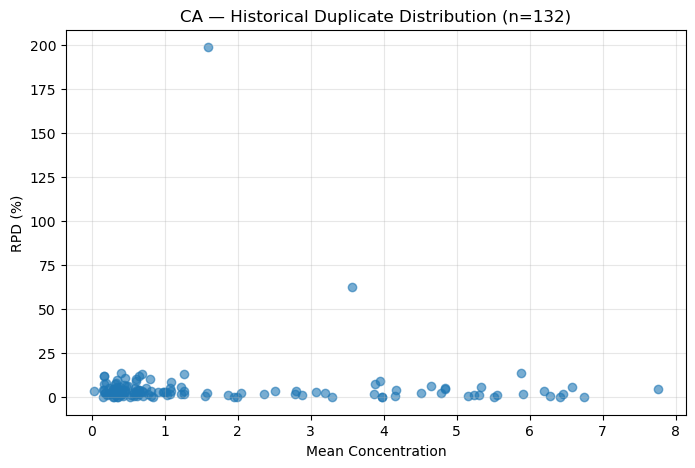

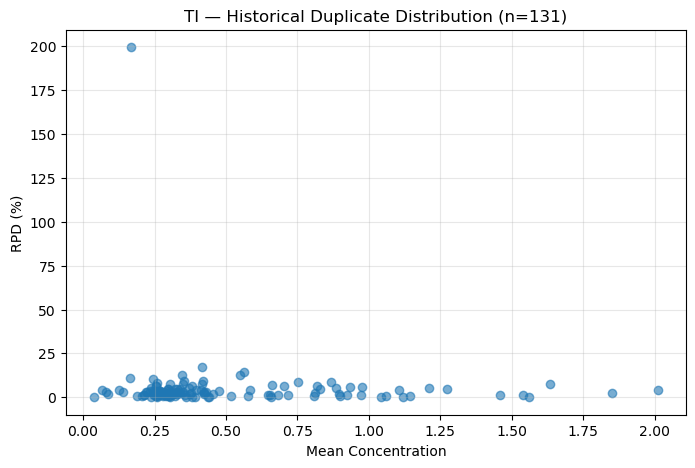

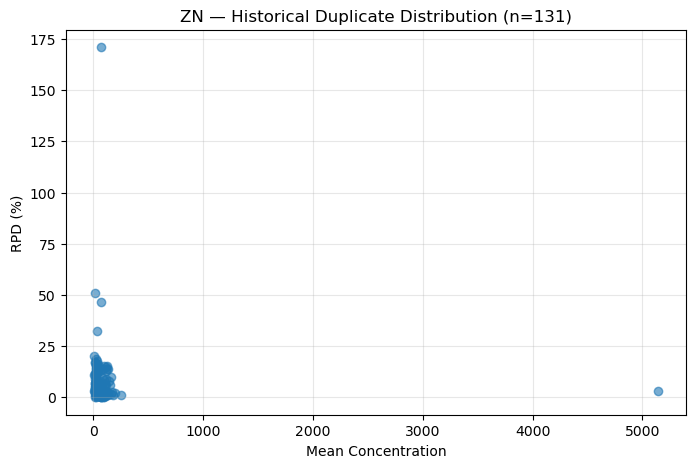

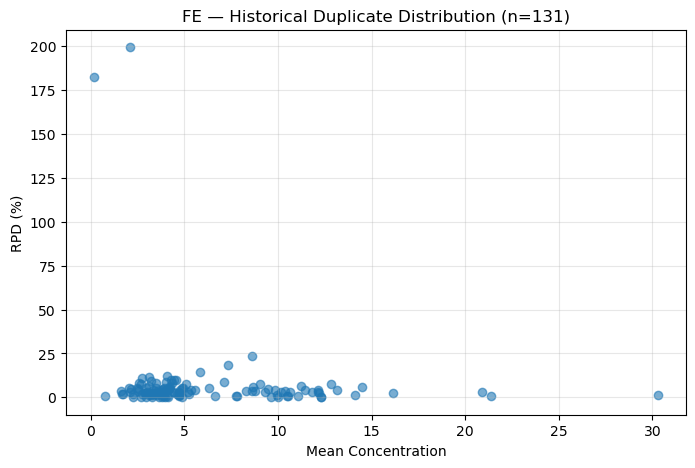

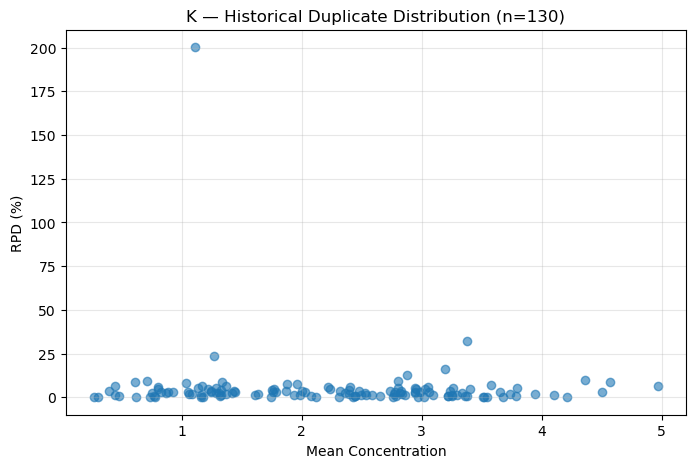

In [8]:
candidate_analytes = concentration_coverage.head(10).index

for analyte in candidate_analytes:
    analyte_df = df_above_dl[
        df_above_dl["ANALYTE_CODE"] == analyte
    ]

    plt.figure(figsize=(8, 5))

    plt.scatter(
        analyte_df["MEAN_CONC"],
        analyte_df["RPD"],
        alpha=0.6
    )

    plt.xlabel("Mean Concentration")
    plt.ylabel("RPD (%)")
    plt.title(
        f"{analyte} — Historical Duplicate Distribution "
        f"(n={len(analyte_df)})"
    )

    plt.grid(alpha=0.3)
    plt.show()
    

In [9]:
# Select pilot analyte
PILOT_ANALYTE = "MN"

df_pilot = (
    df_above_dl[
        df_above_dl["ANALYTE_CODE"] == PILOT_ANALYTE
    ]
    .copy()
    .sort_values("MEAN_CONC")
)

print(f"Analyte: {PILOT_ANALYTE}")
print(f"Observations: {len(df_pilot):,}")
print(
    f"Concentration range: "
    f"{df_pilot['MEAN_CONC'].min():,.3f} "
    f"to {df_pilot['MEAN_CONC'].max():,.3f}"
)

df_pilot.head()


Analyte: MN
Observations: 135
Concentration range: 36.924 to 16,829.724


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_DUP_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_DUP_VALUE,UNIT_CODE,ABOVE_STAT_DL
4279,2020-11-05 10:45:28.000000,MN,76.152000,-2.304000,5.0,36.924000,78.456000,212.48,IgnoreFailure,15.0,MG_KG,True
4776,2020-07-17 11:34:19.000000,MN,111.280000,110.354146,5.0,110.817073,0.925854,0.84,Pass,15.0,MG_KG,True
3786,2020-11-24 10:25:22.000000,MN,150.573529,149.668269,5.0,150.120899,0.905260,0.60,Pass,15.0,MG_KG,True
4752,2020-07-21 09:14:04.000000,MN,158.148187,148.549541,5.0,153.348864,9.598645,6.26,Pass,15.0,MG_KG,True
3033,2021-02-18 13:47:24.000000,MN,185.394652,150.795789,5.0,168.095221,34.598863,20.58,IgnoreFailure,15.0,MG_KG,True


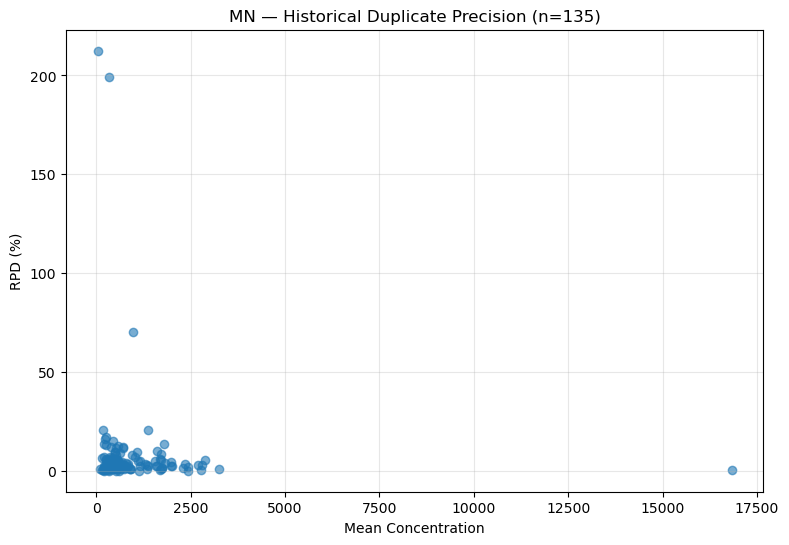

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_pilot["MEAN_CONC"],
    df_pilot["RPD"],
    alpha=0.6
)

plt.xlabel("Mean Concentration")
plt.ylabel("RPD (%)")
plt.title(
    f"{PILOT_ANALYTE} — Historical Duplicate Precision "
    f"(n={len(df_pilot)})"
)

plt.grid(alpha=0.3)
plt.show()


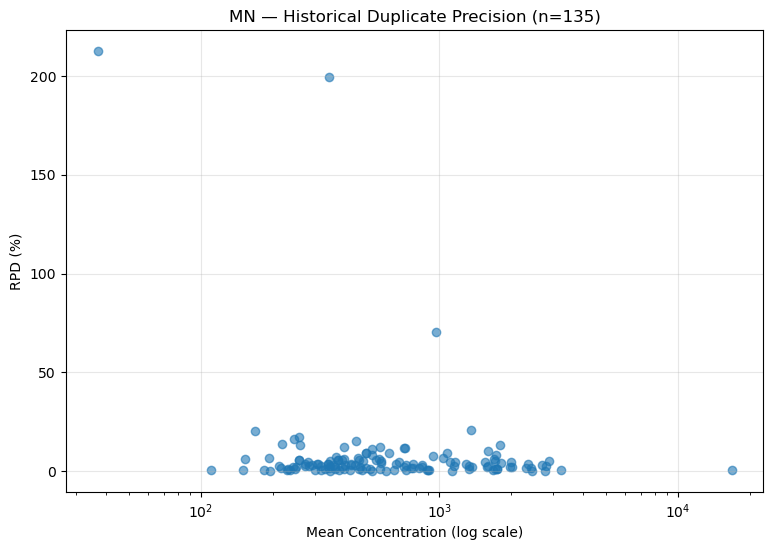

In [11]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_pilot["MEAN_CONC"],
    df_pilot["RPD"],
    alpha=0.6
)

plt.xscale("log")

plt.xlabel("Mean Concentration (log scale)")
plt.ylabel("RPD (%)")
plt.title(
    f"{PILOT_ANALYTE} — Historical Duplicate Precision "
    f"(n={len(df_pilot)})"
)

plt.grid(alpha=0.3)
plt.show()


In [12]:
import statsmodels.formula.api as smf


In [13]:
df_pilot["LOG_MEAN_CONC"] = np.log10(df_pilot["MEAN_CONC"])


In [26]:
quantiles = [0.25, 0.50, 0.75, 0.95]

models = {}

for q in quantiles:
    models[q] = smf.quantreg(
        "RPD ~ LOG_MEAN_CONC",
        df_pilot
    ).fit(q=q)

    print(
        f"Q{int(q * 100):02d}: "
        f"Intercept={models[q].params['Intercept']:.3f}, "
        f"Slope={models[q].params['LOG_MEAN_CONC']:.3f}"
    )
    

Q25: Intercept=1.610, Slope=-0.120
Q50: Intercept=6.651, Slope=-1.307
Q75: Intercept=12.059, Slope=-2.244
Q95: Intercept=40.171, Slope=-9.361


In [27]:
# Generate concentration values across the observed MN range
x_grid = np.linspace(
    df_pilot["LOG_MEAN_CONC"].min(),
    df_pilot["LOG_MEAN_CONC"].max(),
    300
)

prediction_df = pd.DataFrame({
    "LOG_MEAN_CONC": x_grid
})

# Convert back to original concentration for plotting
prediction_df["MEAN_CONC"] = 10 ** prediction_df["LOG_MEAN_CONC"]

# Generate fitted quantile values
for q in quantiles:
    prediction_df[f"Q{int(q * 100):02d}"] = models[q].predict(
        prediction_df
    )
    

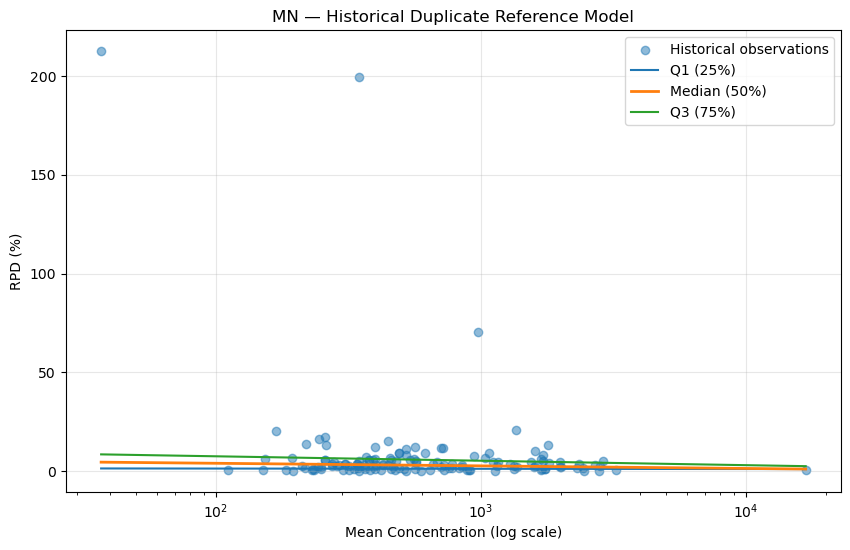

In [28]:
plt.figure(figsize=(10, 6))

# Historical observations
plt.scatter(
    df_pilot["MEAN_CONC"],
    df_pilot["RPD"],
    alpha=0.5,
    label="Historical observations"
)

# Quantile regression lines
plt.plot(
    prediction_df["MEAN_CONC"],
    prediction_df["Q25"],
    label="Q1 (25%)"
)

plt.plot(
    prediction_df["MEAN_CONC"],
    prediction_df["Q50"],
    linewidth=2,
    label="Median (50%)"
)

plt.plot(
    prediction_df["MEAN_CONC"],
    prediction_df["Q75"],
    label="Q3 (75%)"
)

plt.xscale("log")

plt.xlabel("Mean Concentration (log scale)")
plt.ylabel("RPD (%)")
plt.title(
    f"{PILOT_ANALYTE} — Historical Duplicate Reference Model"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()


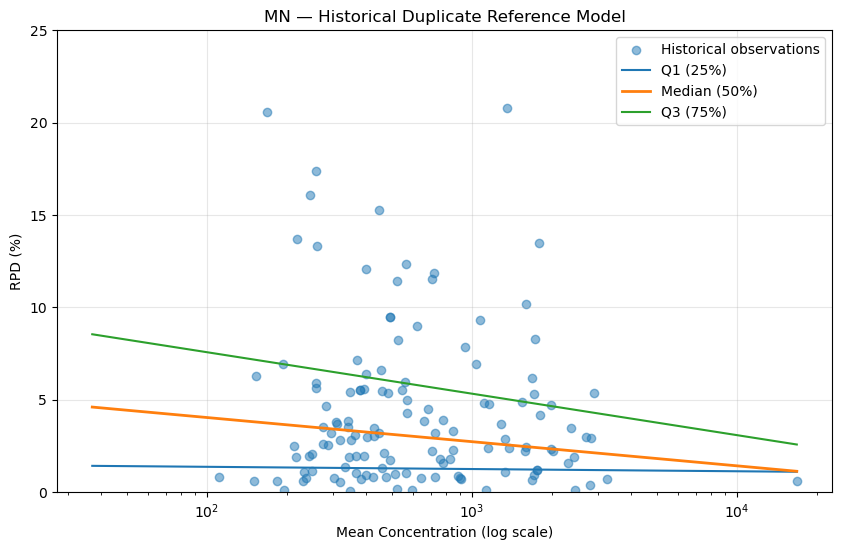

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_pilot["MEAN_CONC"],
    df_pilot["RPD"],
    alpha=0.5,
    label="Historical observations"
)

plt.plot(
    prediction_df["MEAN_CONC"],
    prediction_df["Q25"],
    label="Q1 (25%)"
)

plt.plot(
    prediction_df["MEAN_CONC"],
    prediction_df["Q50"],
    linewidth=2,
    label="Median (50%)"
)

plt.plot(
    prediction_df["MEAN_CONC"],
    prediction_df["Q75"],
    label="Q3 (75%)"
)

plt.xscale("log")
plt.ylim(0, 25)

plt.xlabel("Mean Concentration (log scale)")
plt.ylabel("RPD (%)")
plt.title(
    f"{PILOT_ANALYTE} — Historical Duplicate Reference Model"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [30]:
# Fit nonlinear quantile regression models using B-splines
spline_models = {}

for q in quantiles:
    spline_models[q] = smf.quantreg(
        "RPD ~ bs(LOG_MEAN_CONC, df=4, degree=3)",
        df_pilot
    ).fit(q=q)
    

In [31]:
# Generate spline predictions
spline_prediction_df = prediction_df[
    ["LOG_MEAN_CONC", "MEAN_CONC"]
].copy()

for q in quantiles:
    spline_prediction_df[f"Q{int(q * 100):02d}"] = (
        spline_models[q].predict(spline_prediction_df)
    )
    

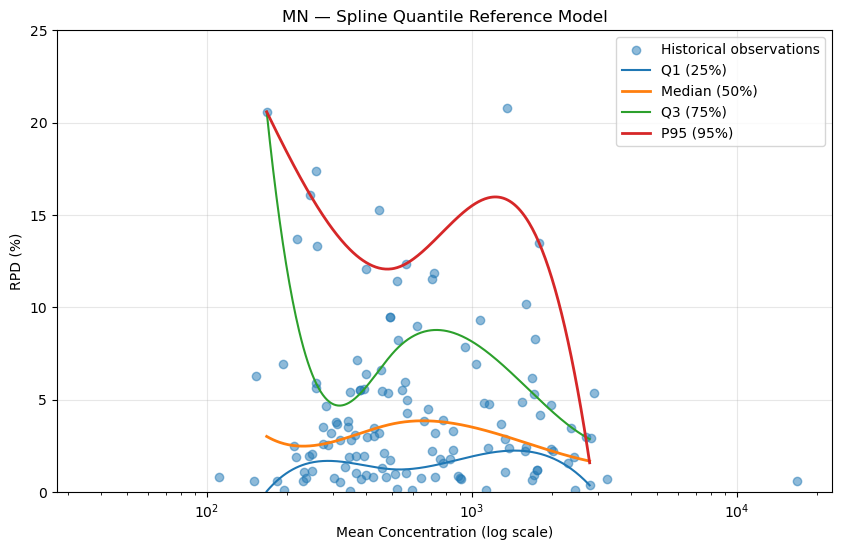

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_pilot["MEAN_CONC"],
    df_pilot["RPD"],
    alpha=0.5,
    label="Historical observations"
)

plt.plot(
    spline_prediction_df["MEAN_CONC"],
    spline_prediction_df["Q25"],
    label="Q1 (25%)"
)

plt.plot(
    spline_prediction_df["MEAN_CONC"],
    spline_prediction_df["Q50"],
    linewidth=2,
    label="Median (50%)"
)

plt.plot(
    spline_prediction_df["MEAN_CONC"],
    spline_prediction_df["Q75"],
    label="Q3 (75%)"
)

plt.plot(
    spline_prediction_df["MEAN_CONC"],
    spline_prediction_df["Q95"],
    linewidth=2,
    label="P95 (95%)"
)

plt.xscale("log")
plt.ylim(0, 25)

plt.xlabel("Mean Concentration (log scale)")
plt.ylabel("RPD (%)")
plt.title(
    f"{PILOT_ANALYTE} — Spline Quantile Reference Model"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [33]:
lower_conc = df_pilot["MEAN_CONC"].quantile(0.025)
upper_conc = df_pilot["MEAN_CONC"].quantile(0.975)

df_model_domain = df_pilot[
    df_pilot["MEAN_CONC"].between(lower_conc, upper_conc)
].copy()

print(f"Model concentration range: {lower_conc:,.2f} to {upper_conc:,.2f}")
print(f"Observations retained: {len(df_model_domain)} of {len(df_pilot)}")


Model concentration range: 158.51 to 2,798.62
Observations retained: 127 of 135


In [34]:
df_model_domain["LOG_MEAN_CONC"] = np.log10(
    df_model_domain["MEAN_CONC"]
)

spline_models = {}

for q in quantiles:
    spline_models[q] = smf.quantreg(
        "RPD ~ bs(LOG_MEAN_CONC, df=4, degree=3)",
        df_model_domain
    ).fit(q=q)
    

In [35]:
x_grid = np.linspace(
    df_model_domain["LOG_MEAN_CONC"].min(),
    df_model_domain["LOG_MEAN_CONC"].max(),
    300
)

spline_prediction_df = pd.DataFrame({
    "LOG_MEAN_CONC": x_grid
})

spline_prediction_df["MEAN_CONC"] = (
    10 ** spline_prediction_df["LOG_MEAN_CONC"]
)

for q in quantiles:
    spline_prediction_df[f"Q{int(q * 100):02d}"] = (
        spline_models[q].predict(spline_prediction_df)
    )
    